# K-Nearest Neighbors (KNN) for Multiclass Credit Risk Grades (A–G)

## What problem are we solving?
We want to predict a borrower’s **credit grade**:

- **Target:** `grade` ∈ {A, B, C, D, E, F, G}  
- **Encoding:** `grade_idx` ∈ {0, 1, 2, 3, 4, 5, 6} (A -> 0, …, G -> 6)

This is a **7-class** multiclass classification task, using only info available **at/before loan issuance**.

## What data are we using?
Final dataset has **24 columns**:
- **2 labels:** `grade`, `grade_idx`
- **22 features:** 4 categorical + 18 numeric

**Categorical features (one-hot):**
- `purpose`, `home_ownership`, `verification_status`, `addr_state`

**Numeric features (examples):**
- `loan_amnt`, `term`, `annual_inc`, `dti`, `revol_util`, `fico_avg`, `open_acc`, `total_acc`, etc.

Splits are **balanced** across grades:
- Train: 59,619 rows (8,517 per grade)
- Dev: 12,775 rows (1,825 per grade)
- Test: 12,782 rows (1,826 per grade)

## What is KNN?
KNN predicts using “similar” borrowers from the training set.

For a new example:
1. Compute distances to all training points  
2. Pick the **K nearest** points  
3. Predict the grade by **majority vote**

So KNN is more like a **lookup method** than a model that learns weights.

## Why do we scale features?
KNN uses distance, so the scale of numbers matters.
Without scaling, big-value features (like income) can dominate the distance.

We do:
- **Standardization** for numeric features (mean/std from **TRAIN only**)
- **One-hot encoding** for categorical features

## What we do here
We test **K = 1 to 10**.
We pick the best K using **dev accuracy**, then report the final **test accuracy**.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Your paths
DATA_ROOT = Path("/content/drive/MyDrive/ML Project/Data")
TRAIN_DIR = DATA_ROOT / "Train"
TEST_DIR  = DATA_ROOT / "Test"

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("TEST_DIR exists :", TEST_DIR.exists())

train_csv = TRAIN_DIR / "train.csv"
dev_csv   = TRAIN_DIR / "dev.csv"
test_csv  = TEST_DIR / "test.csv"

print("Train CSV exists:", train_csv.exists(), "->", train_csv)
print("Dev CSV exists  :", dev_csv.exists(),   "->", dev_csv)
print("Test CSV exists :", test_csv.exists(),  "->", test_csv)


Mounted at /content/drive
DATA_ROOT exists: True
TRAIN_DIR exists: True
TEST_DIR exists : True
Train CSV exists: True -> /content/drive/MyDrive/ML Project/Data/Train/train.csv
Dev CSV exists  : True -> /content/drive/MyDrive/ML Project/Data/Train/dev.csv
Test CSV exists : True -> /content/drive/MyDrive/ML Project/Data/Test/test.csv


Load CSVs + quick sanity checks

In [ ]:
train_df = pd.read_csv(train_csv)
dev_df   = pd.read_csv(dev_csv)
test_df  = pd.read_csv(test_csv)

print("Train shape:", train_df.shape)
print("Dev shape  :", dev_df.shape)
print("Test shape :", test_df.shape)

print("\nColumns:", list(train_df.columns))
print("\nPreview:")
display(train_df.head(3))


Train shape: (59619, 24)
Dev shape  : (12775, 24)
Test shape : (12782, 24)

Columns: ['grade', 'grade_idx', 'purpose', 'home_ownership', 'verification_status', 'addr_state', 'loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_bal', 'revol_util', 'collections_12_mths_ex_med', 'acc_now_delinq', 'pub_rec_bankruptcies', 'tax_liens', 'credit_history_months', 'fico_avg']

Preview:


,grade,grade_idx,purpose,home_ownership,verification_status,addr_state,loan_amnt,term,emp_length,annual_inc,...,total_acc,pub_rec,revol_bal,revol_util,collections_12_mths_ex_med,acc_now_delinq,pub_rec_bankruptcies,tax_liens,credit_history_months,fico_avg
0,D,3,credit_card,RENT,Verified,CA,6000.0,36.0,10.0,65000.0,...,55.0,1.0,1363.0,3.6,0.0,0.0,1.0,0.0,218.020534,677.0
1,G,6,small_business,MORTGAGE,Source Verified,OH,14600.0,36.0,3.0,60000.0,...,11.0,0.0,6995.0,88.5,0.0,0.0,0.0,0.0,259.055441,667.0
2,G,6,debt_consolidation,MORTGAGE,Source Verified,CA,35000.0,36.0,10.0,184000.0,...,22.0,1.0,37361.0,62.7,0.0,0.0,0.0,1.0,128.985626,682.0


## Class distribution check
Even though you created a perfectly balanced dataset, we verify it anyway.
This also helps confirm that `grade` and `grade_idx` are correct.


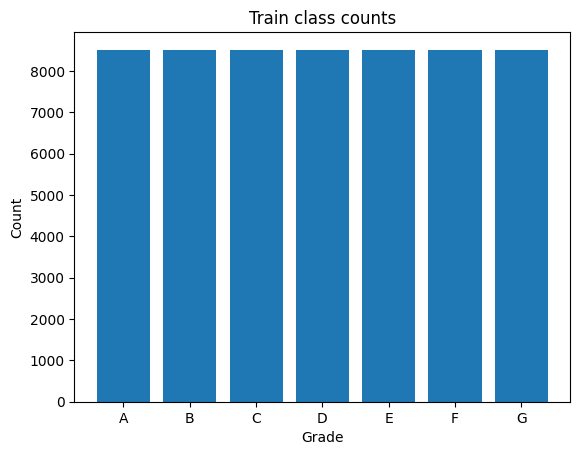

grade
A    8517
B    8517
C    8517
D    8517
E    8517
F    8517
G    8517
Name: count, dtype: int64


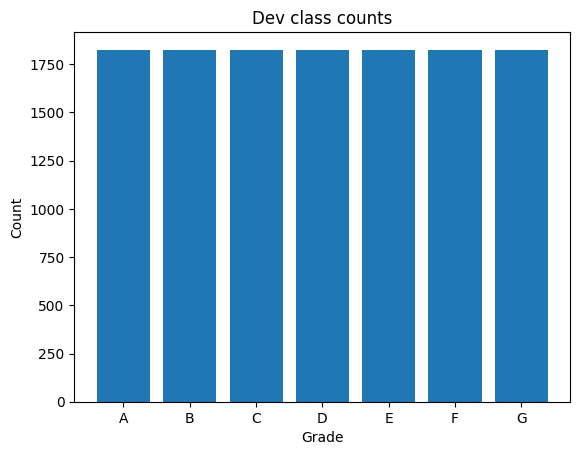

grade
A    1825
B    1825
C    1825
D    1825
E    1825
F    1825
G    1825
Name: count, dtype: int64


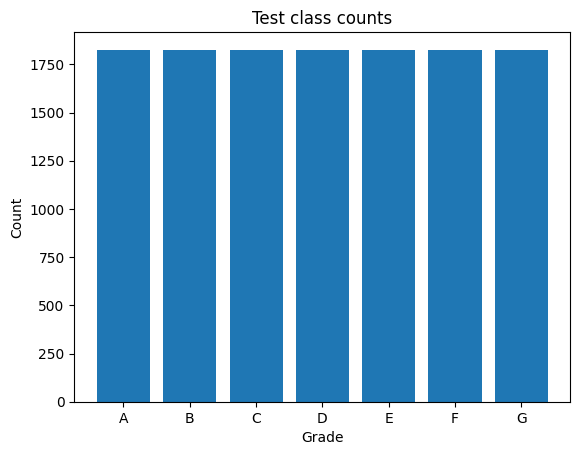

grade
A    1826
B    1826
C    1826
D    1826
E    1826
F    1826
G    1826
Name: count, dtype: int64


In [ ]:
def plot_class_counts(df, title):
    counts = df["grade"].value_counts().sort_index()
    plt.figure()
    plt.bar(counts.index, counts.values)
    plt.title(title)
    plt.xlabel("Grade")
    plt.ylabel("Count")
    plt.show()
    print(counts)

plot_class_counts(train_df, "Train class counts")
plot_class_counts(dev_df,   "Dev class counts")
plot_class_counts(test_df,  "Test class counts")


## Preprocessing for KNN

Since KNN is distance-based, preprocessing matters a lot (otherwise a few columns can dominate).

1) **Categorical -> one hot**
   - `purpose`, `home_ownership`, `verification_status`, `addr_state`

2) **Numeric -> standardize (TRAIN only)**
   - compute mean/std on train, reuse the same values for dev/test

3) **Missing values**
   - numeric: fill with the TRAIN median  
   - categorical: fill with `"MISSING"`

At the end, we make sure dev/test have the **same columns in the same order** as train.


In [ ]:
CATEGORICAL_COLS = ["purpose", "home_ownership", "verification_status", "addr_state"]
LABEL_COL = "grade_idx"

# Numeric columns = everything except labels + categorical + grade string label
def infer_numeric_cols(df):
    exclude = set(CATEGORICAL_COLS + ["grade", "grade_idx"])
    return [c for c in df.columns if c not in exclude]

NUMERIC_COLS = infer_numeric_cols(train_df)
print("Numeric columns:", NUMERIC_COLS)

def fit_preprocess(train_df):
    train = train_df.copy()

    # one hot categories seen in train (we will align dev/test to these columns)
    train_cat = pd.get_dummies(train[CATEGORICAL_COLS], drop_first=False)
    cat_columns = list(train_cat.columns)

    # standardization stats from train
    train_num = train[NUMERIC_COLS].astype(np.float64)
    means = train_num.mean().to_dict()
    stds  = train_num.std().replace(0, 1.0).to_dict()

    return {"means": means, "stds": stds, "cat_columns": cat_columns}

def transform(df, stats):
    out = df.copy()

    # standardize numeric using train stats
    num = out[NUMERIC_COLS].astype(np.float64)
    for c in NUMERIC_COLS:
        num[c] = (num[c] - stats["means"][c]) / stats["stds"][c]

    # one hot encode categorical and align with train columns
    cat = pd.get_dummies(out[CATEGORICAL_COLS], drop_first=False)
    cat = cat.reindex(columns=stats["cat_columns"], fill_value=0)

    # final X and y
    X = np.concatenate([num.to_numpy(dtype=np.float32),
                        cat.to_numpy(dtype=np.float32)], axis=1)
    y = out[LABEL_COL].to_numpy(dtype=np.int64)
    return X, y

# fit on train, transform all splits
stats = fit_preprocess(train_df)

X_train, y_train = transform(train_df, stats)
X_dev, y_dev     = transform(dev_df, stats)
X_test, y_test   = transform(test_df, stats)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_dev  :", X_dev.shape,   "y_dev  :", y_dev.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


Numeric columns: ['loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_bal', 'revol_util', 'collections_12_mths_ex_med', 'acc_now_delinq', 'pub_rec_bankruptcies', 'tax_liens', 'credit_history_months', 'fico_avg']
X_train: (59619, 91) y_train: (59619,)
X_dev  : (12775, 91) y_dev  : (12775,)
X_test : (12782, 91) y_test : (12782,)


## Implementing KNN from scratch
For each query point:
- compute squared Euclidean distance to all train points
- pick K smallest distances
- do majority vote among their labels

To make it fast enough, we compute distances in batches using:
||a-b||² = ||a||² + ||b||² - 2a·b


In [ ]:
def knn_predict(X_train, y_train, X_query, k, num_classes=7, batch_size=256):
    """
    Uses squared Euclidean distance and batched computation.
    """
    n_query = X_query.shape[0]
    y_pred = np.empty(n_query, dtype=np.int64)

    # precompute train norms
    train_norm = np.sum(X_train * X_train, axis=1)  # (n_train,)

    for start in range(0, n_query, batch_size):
        end = min(start + batch_size, n_query)
        Xb = X_query[start:end]                      # (b, d)
        query_norm = np.sum(Xb * Xb, axis=1)         # (b,)

        # dist^2 = ||x||^2 + ||t||^2 - 2 x·t
        dists = query_norm[:, None] + train_norm[None, :] - 2.0 * (Xb @ X_train.T)  # (b, n_train)

        # indices of k nearest
        nn_idx = np.argpartition(dists, kth=k-1, axis=1)[:, :k]  # (b, k)
        nn_labels = y_train[nn_idx]                              # (b, k)

        # majority vote (ties -> smallest class index, due to argmax)
        for i in range(nn_labels.shape[0]):
            counts = np.bincount(nn_labels[i], minlength=num_classes)
            y_pred[start + i] = counts.argmax()

    return y_pred

def accuracy(y_true, y_pred):
    return float((y_true == y_pred).mean())



For each K, we compute:
- Train-eval accuracy (query subset vs remaining reference)
- Dev accuracy (reference = full train)
- Test accuracy (reference = full train)

We will store results in a table and plot accuracy vs K.


In [ ]:
results = []

for k in range(1, 11):
    print(f"\n=== K = {k} ===")

    y_pred_train = knn_predict(X_train, y_train, X_train, k=k, batch_size=256)
    train_acc = accuracy(y_train, y_pred_train)
    print("Train acc:", train_acc)

    y_pred_dev = knn_predict(X_train, y_train, X_dev, k=k, batch_size=256)
    dev_acc = accuracy(y_dev, y_pred_dev)
    print("Dev acc  :", dev_acc)

    y_pred_test = knn_predict(X_train, y_train, X_test, k=k, batch_size=256)
    test_acc = accuracy(y_test, y_pred_test)
    print("Test acc :", test_acc)

    results.append((k, train_acc, dev_acc, test_acc))

results_df = pd.DataFrame(results, columns=["K", "TrainAcc", "DevAcc", "TestAcc"])
display(results_df)



=== K = 1 ===
Train acc: 1.0
Dev acc  : 0.27569471624266145
Test acc : 0.2742137380691598

=== K = 2 ===
Train acc: 0.6205404317415589
Dev acc  : 0.2744422700587084
Test acc : 0.27609137850101706

=== K = 3 ===
Train acc: 0.5605930995152552
Dev acc  : 0.275146771037182
Test acc : 0.2710843373493976

=== K = 4 ===
Train acc: 0.5390395679229776
Dev acc  : 0.28853228962818006
Test acc : 0.28250664997652947

=== K = 5 ===
Train acc: 0.5171673459803083
Dev acc  : 0.2983953033268102
Test acc : 0.2920513221718041

=== K = 6 ===
Train acc: 0.49662020496821485
Dev acc  : 0.3065362035225049
Test acc : 0.2949460178375841

=== K = 7 ===
Train acc: 0.48204431473188075
Dev acc  : 0.30724070450097846
Test acc : 0.2983883586293225

=== K = 8 ===
Train acc: 0.47067210117579966
Dev acc  : 0.30755381604696674
Test acc : 0.30394304490690033

=== K = 9 ===
Train acc: 0.46131266878008687
Dev acc  : 0.30974559686888453
Test acc : 0.30558598028477546

=== K = 10 ===
Train acc: 0.45512336671195425
Dev acc  : 

,K,TrainAcc,DevAcc,TestAcc
0,1,1.000000,0.275695,0.274214
1,2,0.620540,0.274442,0.276091
2,3,0.560593,0.275147,0.271084
3,4,0.539040,0.288532,0.282507
4,5,0.517167,0.298395,0.292051
5,6,0.496620,0.306536,0.294946
6,7,0.482044,0.307241,0.298388
7,8,0.470672,0.307554,0.303943
8,9,0.461313,0.309746,0.305586
9,10,0.455123,0.313581,0.309419


## Choosing the best K
We choose the K that maximizes **Dev accuracy**.
If there is a tie, we choose the smaller K (simpler model).
Then we report the chosen K and its test accuracy.


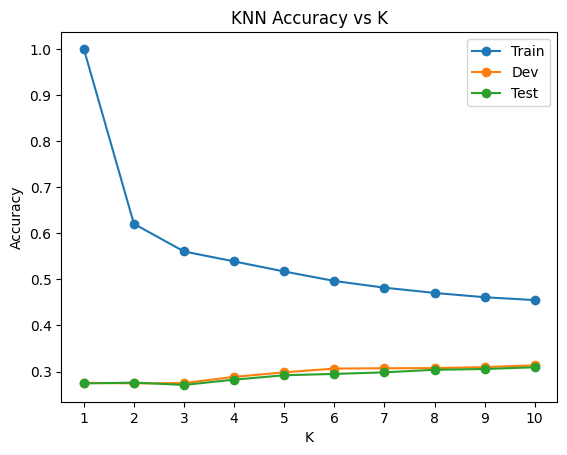

Best K by Dev accuracy: 10
K           10.000000
TrainAcc     0.455123
DevAcc       0.313581
TestAcc      0.309419
Name: 9, dtype: float64


In [ ]:
plt.figure()
plt.plot(results_df["K"], results_df["TrainAcc"], marker="o", label="Train")
plt.plot(results_df["K"], results_df["DevAcc"],   marker="o", label="Dev")
plt.plot(results_df["K"], results_df["TestAcc"],  marker="o", label="Test")
plt.xticks(results_df["K"])
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.legend()
plt.show()

best_row = results_df.sort_values(["DevAcc", "K"], ascending=[False, True]).iloc[0]
best_k = int(best_row["K"])
print("Best K by Dev accuracy:", best_k)
print(best_row)


## Confusion Matrix (Best K)
A confusion matrix shows *which grades get confused with which*.
For LendingClub grades, it's common to see confusion between neighboring risk grades (example C vs D).


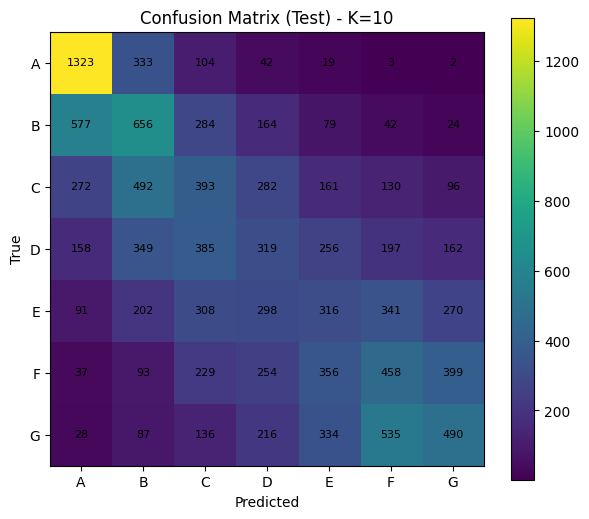

Test accuracy (best K): 0.3094194961664841


In [ ]:
def confusion_matrix(y_true, y_pred, num_classes=7):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

# Predict test with best K
y_pred_test_best = knn_predict(X_train, y_train, X_test, k=best_k, batch_size=256)
cm = confusion_matrix(y_test, y_pred_test_best, num_classes=7)

labels = ["A","B","C","D","E","F","G"]

plt.figure(figsize=(7,6))
plt.imshow(cm)
plt.title(f"Confusion Matrix (Test) - K={best_k}")
plt.xticks(range(7), labels)
plt.yticks(range(7), labels)
plt.xlabel("Predicted")
plt.ylabel("True")

# annotate
for i in range(7):
    for j in range(7):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)

plt.colorbar()
plt.show()

print("Test accuracy (best K):", accuracy(y_test, y_pred_test_best))


### KNN Results (K = 1 to 10)

We tried **K = 1 to 10** and tracked accuracy on Train / Dev / Test.

- At **K = 1**, train accuracy hits **1.0** because every point just matches itself. But **Dev/Test stay low (~0.27)**, so it’s basically overfitting.
- As **K goes up**, train accuracy drops (expected), but **Dev and Test slowly improve**, which usually means the model is generalizing a bit better.
- The best dev score we got was at **K = 10**: **Dev = 0.3136**, and **Test = 0.3094**.

So for this data, using a **bigger K** helped since it averages over more neighbors and isn’t as sensitive to random/noisy points.
